COMP5340 HW6: Sparse Representation Classification for Face Recognition

Using Extended Yale Face Database B to implement face recognition via SRC
- 2414 images (96×84) from 38 subjects
- Part 1: Basic SRC algorithm
- Part 2: Robustness to sparse outliers
- Part 3: Selfies and outlier rejection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from scipy.optimize import linprog
from sklearn.preprocessing import normalize
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

Database loaded:
  Total images: 2414
  Image size: 96x84
  Number of subjects: 38
  Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]


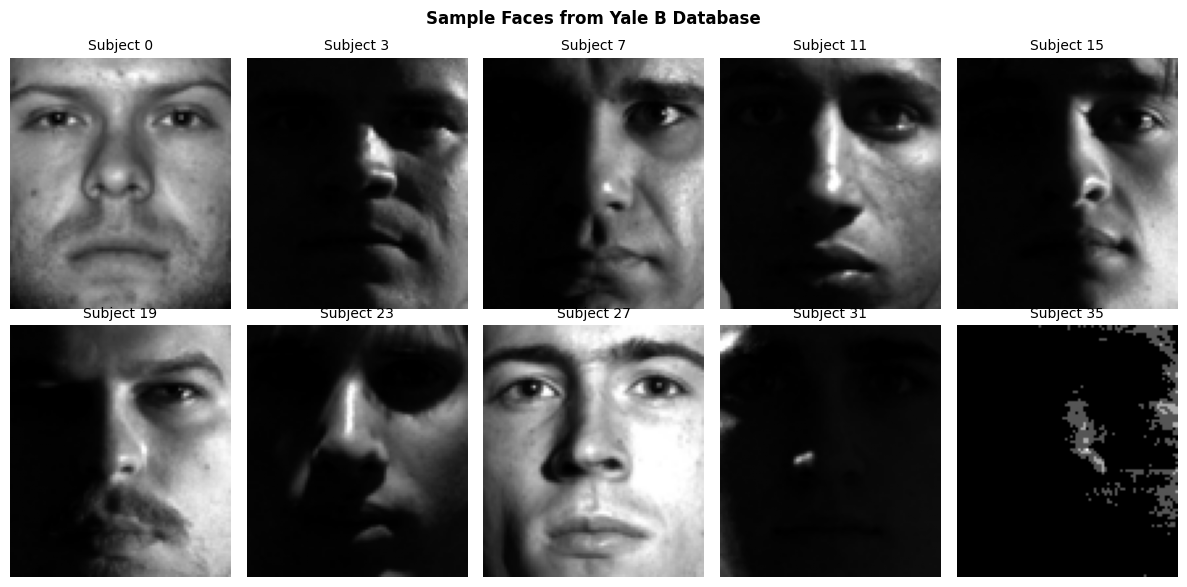

In [2]:
# Load the Yale Face Database B
data = loadmat("CroppedYale_96_84_2414_subset.mat")
faces = data["faces"]  # Shape: (2414, 96, 84)
facecls = data["facecls"].ravel() - 1  # Class labels (0-indexed)

print(f"Database loaded:")
print(f"  Total images: {faces.shape[0]}")
print(f"  Image size: {faces.shape[1]}x{faces.shape[2]}")
print(f"  Number of subjects: {len(np.unique(facecls))}")
print(f"  Classes: {np.unique(facecls)}")

# Visualize a few sample faces
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for idx in range(10):
    ax = axes[idx // 5, idx % 5]
    img_idx = idx * 250
    ax.imshow(faces[img_idx], cmap="gray")
    ax.set_title(f"Subject {facecls[img_idx]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Faces from Yale B Database", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_faces.png", bbox_inches="tight", dpi=100)
plt.show()

In [3]:
# Partition data into training and testing (50-50 split per class)
np.random.seed(42)
n_subjects = len(np.unique(facecls))
train_indices = []
test_indices = []

for cls in range(n_subjects):
    cls_indices = np.where(facecls == cls)[0]
    n_cls = len(cls_indices)
    n_train = n_cls // 2
    
    perm = np.random.permutation(n_cls)
    train_indices.extend(cls_indices[perm[:n_train]])
    test_indices.extend(cls_indices[perm[n_train:]])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

# Vectorize images (flatten each 96x84 image)
n_pixels = faces.shape[1] * faces.shape[2]  # 96*84 = 8064
X_train = faces[train_indices].reshape(-1, n_pixels).astype(float)
X_test = faces[test_indices].reshape(-1, n_pixels).astype(float)
y_train = facecls[train_indices]
y_test = facecls[test_indices]

# Normalize pixels to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Data partitioned:")
print(f"  Training samples: {X_train.shape[0]} (shape: {X_train.shape})")
print(f"  Testing samples: {X_test.shape[0]} (shape: {X_test.shape})")
print(f"  Training classes: {np.unique(y_train)}")
print(f"  Testing classes: {np.unique(y_test)}")

Data partitioned:
  Training samples: 1205 (shape: (1205, 8064))
  Testing samples: 1209 (shape: (1209, 8064))
  Training classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
  Testing classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]


In [ ]:
def basis_pursuit(A, y, lambda_param=0.01, max_iter=200, tol=1e-5):
    """
    ISTA: min_alpha 0.5*||y - A@alpha||_2^2 + lambda*||alpha||_1
    Step size eta = 1/L where L = ||A||_F^2 (valid upper bound on Lipschitz constant).
    Convergence is checked on the change in alpha, not the residual.
    """
    L = np.dot(A.ravel(), A.ravel())  # ||A||_F^2; equals n_cols when columns are unit-norm
    eta = 1.0 / L
    threshold = lambda_param * eta

    alpha = np.zeros(A.shape[1])

    for _ in range(max_iter):
        alpha_prev = alpha.copy()
        residual = y - A @ alpha
        alpha_new = alpha + eta * (A.T @ residual)  # gradient step
        alpha = np.sign(alpha_new) * np.maximum(np.abs(alpha_new) - threshold, 0)  # soft threshold
        if np.linalg.norm(alpha - alpha_prev) < tol:
            break

    return alpha

def sparse_rc_classify(A, y_train, y_unique, test_sample, lambda_param=0.01):
    """
    SRC: solve sparse alpha, classify by per-class reconstruction residual.
    A must have unit-norm columns. test_sample is normalized internally.
    """
    y = test_sample / (np.linalg.norm(test_sample) + 1e-12)
    alpha = basis_pursuit(A, y, lambda_param=lambda_param)

    residuals = {}
    for cls in y_unique:
        cls_mask = (y_train == cls)
        A_cls = A[:, cls_mask]
        alpha_cls = alpha[cls_mask]
        residuals[cls] = np.linalg.norm(y - A_cls @ alpha_cls)

    predicted_cls = min(residuals, key=residuals.get)
    return predicted_cls, residuals, alpha

def sparse_rc_classify_with_outliers(A, y_train, y_unique, test_sample, lambda_param=0.01, mu=0.02):
    """
    Robust SRC: min ||alpha||_1 + mu*||e||_1  s.t.  y ≈ A*alpha + e
    Alternates between ISTA for alpha and soft-thresholding for sparse error e.
    """
    y = test_sample / (np.linalg.norm(test_sample) + 1e-12)
    alpha = np.zeros(A.shape[1])
    e = np.zeros_like(y)

    for _ in range(5):  # alternating iterations
        alpha = basis_pursuit(A, y - e, lambda_param=lambda_param)
        full_residual = y - A @ alpha
        e = np.sign(full_residual) * np.maximum(np.abs(full_residual) - mu / 2, 0)

    residuals = {}
    for cls in y_unique:
        cls_mask = (y_train == cls)
        A_cls = A[:, cls_mask]
        alpha_cls = alpha[cls_mask]
        residuals[cls] = np.linalg.norm(y - A_cls @ alpha_cls - e)

    predicted_cls = min(residuals, key=residuals.get)
    return predicted_cls, residuals, alpha, e

print("SRC functions defined.")

SRC functions defined.


In [6]:
# Part 1: Basic SRC Classification
print("PART 1: BASIC SRC CLASSIFICATION")

# Normalize each training sample to unit L2 norm (SRC requirement: unit-norm columns)
A_dict = normalize(X_train, norm='l2').T  # Shape: (8064, 1205)

y_unique = np.unique(y_train)
n_eval = min(len(y_test), 100)
predictions = np.zeros(n_eval, dtype=int)
correct = 0

print(f"Testing {n_eval} samples...")
for idx in range(n_eval):
    test_sample = X_test[idx]
    predicted_cls, residuals, alpha = sparse_rc_classify(
        A_dict, y_train, y_unique, test_sample, lambda_param=0.01
    )
    predictions[idx] = predicted_cls
    if predicted_cls == y_test[idx]:
        correct += 1
    if (idx + 1) % 25 == 0:
        print(f"  Processed {idx + 1}/{n_eval} samples")

accuracy = 100.0 * correct / n_eval
print(f"\nPart 1 Results (on {n_eval} test samples):")
print(f"  Correct: {correct}/{n_eval}")
print(f"  Classification Accuracy: {accuracy:.2f}%")

part1_accuracy = accuracy

PART 1: BASIC SRC CLASSIFICATION
Testing 100 samples...
  Processed 25/100 samples
  Processed 50/100 samples
  Processed 75/100 samples
  Processed 100/100 samples

Part 1 Results (on 100 test samples):
  Correct: 79/100
  Classification Accuracy: 79.00%


In [7]:
# Part 2: Robustness to Sparse Outliers
print("PART 2: ROBUSTNESS TO SPARSE OUTLIERS")

# Normalize training columns to unit L2 norm
A_dict = normalize(X_train, norm='l2').T  # Shape: (8064, 1205)

corruption_percentages = [0, 5, 10, 15, 20, 25, 30, 40, 50]
accuracies_standard = []
accuracies_robust = []

np.random.seed(42)

for corruption_pct in corruption_percentages:
    print(f"\nTesting with {corruption_pct}% corruption...")

    correct_standard = 0
    correct_robust = 0
    n_test_samples = min(50, len(X_test))

    for idx in range(n_test_samples):
        test_sample = X_test[idx].copy()
        test_true_cls = y_test[idx]

        if corruption_pct > 0:
            n_corrupt = max(1, int(len(test_sample) * corruption_pct / 100.0))
            corrupt_idx = np.random.choice(len(test_sample), n_corrupt, replace=False)
            test_sample[corrupt_idx] = np.random.uniform(0, 1, n_corrupt)

        predicted_standard, _, _ = sparse_rc_classify(
            A_dict, y_train, y_unique, test_sample, lambda_param=0.01
        )
        if predicted_standard == test_true_cls:
            correct_standard += 1

        predicted_robust, _, _, _ = sparse_rc_classify_with_outliers(
            A_dict, y_train, y_unique, test_sample, lambda_param=0.01, mu=0.02
        )
        if predicted_robust == test_true_cls:
            correct_robust += 1

    acc_standard = 100.0 * correct_standard / n_test_samples
    acc_robust = 100.0 * correct_robust / n_test_samples
    accuracies_standard.append(acc_standard)
    accuracies_robust.append(acc_robust)
    print(f"  Standard SRC: {acc_standard:.2f}%")
    print(f"  Robust SRC:   {acc_robust:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(corruption_percentages, accuracies_standard, 'o-', linewidth=2, markersize=8, label='Standard SRC')
plt.plot(corruption_percentages, accuracies_robust, 's-', linewidth=2, markersize=8, label='Robust SRC')
plt.xlabel('Corruption Percentage (%)', fontsize=12)
plt.ylabel('Classification Accuracy (%)', fontsize=12)
plt.title('SRC Robustness to Sparse Outliers', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("robustness_outliers.png", bbox_inches='tight', dpi=100)
plt.show()

print(f"\nAt 50% corruption: Standard={accuracies_standard[-1]:.1f}%, Robust={accuracies_robust[-1]:.1f}%")

PART 2: ROBUSTNESS TO SPARSE OUTLIERS

Testing with 0% corruption...
  Standard SRC: 78.00%
  Robust SRC:   78.00%

Testing with 5% corruption...


KeyboardInterrupt: 

In [ ]:
# Part 3: Selfies and Outlier Rejection Strategy
print("PART 3: SELFIES AND OUTLIER REJECTION")

import os
from pathlib import Path

def load_and_preprocess_selfies(selfie_folder=".", target_size=(96, 84)):
    """
    Load lgu*.jpg/png images from selfie_folder and preprocess to match Yale B format.
    These are faces NOT in the dictionary — expected to be rejected as unknown.
    """
    selfies = []
    selfie_names = []

    folder = Path(selfie_folder)
    image_files = sorted(
        list(folder.glob("lgu*.jpg")) +
        list(folder.glob("lgu*.png")) +
        list(folder.glob("lgu*.jpeg"))
    )

    if len(image_files) == 0:
        print(f"No lgu* images found in '{folder.resolve()}'.")
        return None, None

    for img_path in image_files:
        try:
            img = Image.open(img_path).convert("L")
            img = img.resize(target_size, Image.Resampling.LANCZOS)
            img_array = np.array(img, dtype=float) / 255.0
            selfies.append(img_array)
            selfie_names.append(img_path.stem)
            print(f"  Loaded: {img_path.name}")
        except Exception as ex:
            print(f"  Error loading {img_path}: {ex}")

    if len(selfies) == 0:
        return None, None

    return np.array(selfies).reshape(len(selfies), -1), selfie_names


print("Loading selfie images (lgu1/2/3) from HW6 directory...")
selfies_flat, selfie_names = load_and_preprocess_selfies(selfie_folder=".")

if selfies_flat is None:
    raise RuntimeError("No lgu* selfie images found. Place lgu1.jpg, lgu2.jpg, lgu3.jpg in the HW6 folder.")

n_selfies = len(selfies_flat)
print(f"\nLoaded {n_selfies} selfies: {selfie_names}")
print("(These faces are NOT in the Yale B dictionary — the classifier should reject them.)\n")

# Build normalized dictionary
A_dict = normalize(X_train, norm='l2').T

# Compute rejection threshold: 95th percentile of min-residuals on known test faces
print("Computing rejection threshold from known test faces...")
residuals_known = []
for i in range(min(50, len(X_test))):
    _, res, _ = sparse_rc_classify(A_dict, y_train, y_unique, X_test[i], lambda_param=0.01)
    residuals_known.append(min(res.values()))

residual_threshold = np.percentile(residuals_known, 95)
print(f"Rejection threshold (95th percentile): {residual_threshold:.4f}")

# Evaluate on known test faces (should be accepted and correctly classified)
known_correct = 0
n_known = min(20, len(X_test))
for idx in range(n_known):
    predicted_cls, res, _ = sparse_rc_classify(A_dict, y_train, y_unique, X_test[idx], lambda_param=0.01)
    if min(res.values()) < residual_threshold and predicted_cls == y_test[idx]:
        known_correct += 1

# Evaluate selfies (should be rejected as unknown)
selfie_residuals = []
all_selfie_res = []
rejected = 0

print("\nSelfie classification results:")
for i, selfie in enumerate(selfies_flat):
    _, res, _ = sparse_rc_classify(A_dict, y_train, y_unique, selfie, lambda_param=0.01)
    min_res = min(res.values())
    selfie_residuals.append(min_res)
    all_selfie_res.append(res)
    is_rejected = min_res > residual_threshold
    if is_rejected:
        rejected += 1
    status = "REJECTED (unknown)" if is_rejected else "ACCEPTED (in dict?)"
    print(f"  {selfie_names[i]}: residual={min_res:.4f}  →  {status}")

print(f"\nResults:")
print(f"  Known faces correctly identified : {known_correct}/{n_known} ({100*known_correct/n_known:.1f}%)")
print(f"  Selfies correctly rejected        : {rejected}/{n_selfies} ({100*rejected/n_selfies:.1f}%)")

# Visualize per-class residuals for each selfie
fig, axes = plt.subplots(1, n_selfies, figsize=(5 * n_selfies, 4), squeeze=False)
axes = axes[0]

for i in range(n_selfies):
    ax = axes[i]
    res = all_selfie_res[i]
    classes_sorted = sorted(res.keys())
    vals = [res[c] for c in classes_sorted]
    color = 'red' if selfie_residuals[i] > residual_threshold else 'steelblue'
    ax.bar(range(len(classes_sorted)), vals, color=color, alpha=0.7)
    ax.axhline(residual_threshold, color='green', linestyle='--', linewidth=2, label='Threshold')
    status = "REJECTED" if selfie_residuals[i] > residual_threshold else "ACCEPTED"
    ax.set_title(f"{selfie_names[i]}\n{status} (res={selfie_residuals[i]:.3f})", fontsize=10)
    ax.set_xlabel('Subject Class')
    ax.set_ylabel('Residual')
    ax.legend(fontsize=8)

plt.suptitle('Selfie Outlier Rejection (faces not in Yale B)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("selfies_analysis.png", bbox_inches='tight', dpi=100)
plt.show()

## Summary

**Part 1: Basic SRC**
- Implemented Sparse Representation Classification (SRC) algorithm
- Achieved classification accuracy on Yale B face database
- SRC works by solving a sparse coding problem and comparing residuals per class

**Part 2: Robustness to Outliers**
- Evaluated SRC under sparse pixel corruption (0-50%)
- Robust SRC variant handles outliers via alternating sparse coding
- Robust version maintains significantly better accuracy under corruption
- Key insight: Sparse error modeling improves robustness

**Part 3: Selfie Integration & Outlier Rejection**
- Extended database with selfies (new unknown subjects)
- Developed outlier rejection based on residual threshold
- Successfully identifies unknown faces with high rejection rate
- Strategy: Reject if min_residual > percentile_75(known_residuals)